In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import math
#%pip install seaborn
import seaborn as sns

car_data = pd.read_csv("./car_dataset.csv")
seller_data = pd.read_csv("./seller_dataset.csv")
raw_car_data = car_data.copy() 
raw_seller_data = seller_data.copy()

In [2]:
car_data.head()


,ad_id,origin,condition,car_model,mileage,exterior_color,interior_color,num_of_doors,seating_capacity,engine,fuel_system,transmission,drive_type,fuel_consumption,brand,grade,year_of_manufacture,car_name,price (AUD)
0,17042,Domestic assembly,New car,Truck,0 Km,White,gray,2-door,2-seat,Petrol\t1.0 L,NaN,Manual,RFD - Rear-wheel drive,L/100Km,Suzuki,Super Carry Truck,2022.0,Suzuki Super Carry Truck 1.0 MT 2022,10080.99411
1,53794,Imported,New car,SUV,0 Km,Black,Black,5-door,7-seat,Petrol\t3.4 L,NaN,Automatic,AWD - 4-wheel drive (AWD),10\tL/100Km,Toyota,Land Cruiser,2022.0,Toyota Land Cruiser 3.5 V6 2022,161943.68050
2,73954,Domestic assembly,New car,Crossover,0 Km,Silver,Brown,5-door,8-seat,Petrol\t2.0 L,NaN,Automatic,RFD - Rear-wheel drive,L/100Km,Toyota,Innova,2023.0,Toyota Innova G 2.0 AT 2023 car,35830.03930
3,74150,Imported,New car,SUV,0 Km,White,Black,5-door,5-seat,Petrol\t1.8 L,NaN,Automatic,FWD - Front-wheel drive,L/100Km,Toyota,Corolla Cross,2023.0,Toyota Corolla Cross 1.8G 2023,30526.38376
4,87573,Domestic assembly,New car,Crossover,0 Km,Silver,gray,5-door,8-seat,Petrol\t2.0 L,NaN,Automatic,RFD - Rear-wheel drive,L/100Km,Toyota,Innova,2022.0,Toyota Innova G 2.0 AT 2022 car,34413.03209


In [3]:
print(car_data.columns.tolist())

['ad_id', 'origin', 'condition', 'car_model', 'mileage', 'exterior_color', 'interior_color', 'num_of_doors', 'seating_capacity', 'engine', 'fuel_system', 'transmission', 'drive_type', 'fuel_consumption', 'brand', 'grade', 'year_of_manufacture', 'car_name', 'price (AUD)']


In [4]:
#checking the formats of data entered and which part of the data is useful

# def peek(col, n=15):
#     print(col, "->", car_data[col].dtype)
#     print(pd.Series(car_data[col].astype(str).str.strip().unique()).to_list(), "\n")

# peek('num_of_doors'); peek('seating_capacity'); peek('fuel_consumption'); peek('mileage'); peek('price (AUD)'); peek('engine')


def peek(col, n=50):
    print(col, "->", car_data[col].dtype)
    print(pd.Series(car_data[col].astype(str).str.strip().unique()).to_list(), "\n")
    

peek("num_of_doors"); peek("seating_capacity"); peek('fuel_consumption'); peek('mileage'); peek('price (AUD)'); 
peek('engine')

num_of_doors -> object
['2-door', '5-door', '4-door', '6-door', '1-door', '3-door', '45-door', '44-door', '7-door', '54-door', '0-door', '42-door'] 

seating_capacity -> object
['2-seat', '7-seat', '8-seat', '5-seat', '3-seat', '4-seat', '6-seat', '16-seat', '20-seat', '47-seat', '10-seat', '29-seat', '11-seat', '9-seat', '42-seat', '15-seat', '17-seat', '12-seat', '38-seat', '30-seat', '1-seat', '44-seat', '0-seat', '46-seat'] 

fuel_consumption -> object
['L/100Km', '10\tL/100Km', '7\tL/100Km', '9\tL/100Km', '6\tL/100Km', '8\tL/100Km', '5\tL/100Km', '15\tL/100Km', '16\tL/100Km', '4\tL/100Km', '12\tL/100Km', '11\tL/100Km', '2\tL/100Km', '20\tL/100Km', '13\tL/100Km', '14\tL/100Km', '0\tL/100Km', '65\tL/100Km', '66\tL/100Km', '05\tL/100Km', '07\tL/100Km', '08\tL/100Km', '17\tL/100Km', '42\tL/100Km', '7l\tL/100Km', '18\tL/100Km', '3\tL/100Km', '06\tL/100Km', '09\tL/100Km', '1\tL/100Km', '9.\tL/100Km', '565\tL/100Km', '68\tL/100Km', '7.5\tL/100Km', '100\tL/100Km', '77\tL/100Km', '7L\tL/10

In [5]:
# lets start with "num_of_doors", "seating_capacity", "milage" and "fuel_consumption" as they have similar structure --> number-text, we can get rid of just the "text" part here
numerical_cols = ['mileage', 'num_of_doors', 'seating_capacity', 'fuel_consumption', 'price (AUD)']

for col in numerical_cols:
    car_data[col] = pd.to_numeric(
        car_data[col].astype(str).str.extract(r'^(\d+(?:\.\d+)?)', expand=False),
        errors='coerce'
    )
    
# car_data[numerical_cols].dtypes
# car_data[numerical_cols].head(10)
car_data.head()


,ad_id,origin,condition,car_model,mileage,exterior_color,interior_color,num_of_doors,seating_capacity,engine,fuel_system,transmission,drive_type,fuel_consumption,brand,grade,year_of_manufacture,car_name,price (AUD)
0,17042,Domestic assembly,New car,Truck,0,White,gray,2,2,Petrol\t1.0 L,NaN,Manual,RFD - Rear-wheel drive,NaN,Suzuki,Super Carry Truck,2022.0,Suzuki Super Carry Truck 1.0 MT 2022,10080.99411
1,53794,Imported,New car,SUV,0,Black,Black,5,7,Petrol\t3.4 L,NaN,Automatic,AWD - 4-wheel drive (AWD),10.0,Toyota,Land Cruiser,2022.0,Toyota Land Cruiser 3.5 V6 2022,161943.68050
2,73954,Domestic assembly,New car,Crossover,0,Silver,Brown,5,8,Petrol\t2.0 L,NaN,Automatic,RFD - Rear-wheel drive,NaN,Toyota,Innova,2023.0,Toyota Innova G 2.0 AT 2023 car,35830.03930
3,74150,Imported,New car,SUV,0,White,Black,5,5,Petrol\t1.8 L,NaN,Automatic,FWD - Front-wheel drive,NaN,Toyota,Corolla Cross,2023.0,Toyota Corolla Cross 1.8G 2023,30526.38376
4,87573,Domestic assembly,New car,Crossover,0,Silver,gray,5,8,Petrol\t2.0 L,NaN,Automatic,RFD - Rear-wheel drive,NaN,Toyota,Innova,2022.0,Toyota Innova G 2.0 AT 2022 car,34413.03209


In [6]:
# "Price" colmn -> check if there are only digits or any extra things, if yes--> convert it to number then round it off to the closest integer.
# split engine into engine_Type and Engine_capacity

split_cols = car_data['engine'].astype(str).str.split('\t', n=1, expand=True)

car_data['type_of_engine'] = split_cols[0].str.strip().str.title()

car_data['engine_capacity'] = (
    split_cols[1]
    .str.replace('L', '', case=False, regex=False)
    .str.strip()
    .astype(str)
    .str.extract(r'^(\d+(?:\.\d+)?)', expand=False)
    .pipe(pd.to_numeric, errors='coerce')
)


car_data.head()
peek('type_of_engine')

#car_data.drop(columns=['engine'], inplace=True)


type_of_engine -> object
['Petrol', 'Diesel', 'Hybrid', 'Electric', '-'] 



In [7]:
for col in car_data.columns:
    print(col, "-->",car_data[col].dtype)

ad_id --> int64
origin --> object
condition --> object
car_model --> object
mileage --> int64
exterior_color --> object
interior_color --> object
num_of_doors --> int64
seating_capacity --> int64
engine --> object
fuel_system --> object
transmission --> object
drive_type --> object
fuel_consumption --> float64
brand --> object
grade --> object
year_of_manufacture --> float64
car_name --> object
price (AUD) --> float64
type_of_engine --> object
engine_capacity --> float64


In [8]:
text_entries = ['origin', 'condition', 'car_model', 'exterior_color', 'interior_color', 'type_of_engine',
'fuel_system', 'transmission', 'drive_type', 'brand', 'grade']

for cols in text_entries:
    car_data[cols] = car_data[cols].astype(str).str.lower()
    
    
car_data.head()

,ad_id,origin,condition,car_model,mileage,exterior_color,interior_color,num_of_doors,seating_capacity,engine,...,transmission,drive_type,fuel_consumption,brand,grade,year_of_manufacture,car_name,price (AUD),type_of_engine,engine_capacity
0,17042,domestic assembly,new car,truck,0,white,gray,2,2,Petrol\t1.0 L,...,manual,rfd - rear-wheel drive,NaN,suzuki,super carry truck,2022.0,Suzuki Super Carry Truck 1.0 MT 2022,10080.99411,petrol,1.0
1,53794,imported,new car,suv,0,black,black,5,7,Petrol\t3.4 L,...,automatic,awd - 4-wheel drive (awd),10.0,toyota,land cruiser,2022.0,Toyota Land Cruiser 3.5 V6 2022,161943.68050,petrol,3.4
2,73954,domestic assembly,new car,crossover,0,silver,brown,5,8,Petrol\t2.0 L,...,automatic,rfd - rear-wheel drive,NaN,toyota,innova,2023.0,Toyota Innova G 2.0 AT 2023 car,35830.03930,petrol,2.0
3,74150,imported,new car,suv,0,white,black,5,5,Petrol\t1.8 L,...,automatic,fwd - front-wheel drive,NaN,toyota,corolla cross,2023.0,Toyota Corolla Cross 1.8G 2023,30526.38376,petrol,1.8
4,87573,domestic assembly,new car,crossover,0,silver,gray,5,8,Petrol\t2.0 L,...,automatic,rfd - rear-wheel drive,NaN,toyota,innova,2022.0,Toyota Innova G 2.0 AT 2022 car,34413.03209,petrol,2.0


In [9]:
# Min-Max Normalization Formula: x' = (x - min) / (max - min)

numeric_cols = ["engine_capacity", "num_of_doors", "seating_capacity", "fuel_consumption", "price (AUD)"]

for col in numeric_cols:
    if col in car_data.columns:
        min_val = car_data[col].min()
        max_val = car_data[col].max()
        car_data["normalised_" + col] = (car_data[col] - min_val) / (max_val - min_val)


car_data.head()

,ad_id,origin,condition,car_model,mileage,exterior_color,interior_color,num_of_doors,seating_capacity,engine,...,year_of_manufacture,car_name,price (AUD),type_of_engine,engine_capacity,normalised_engine_capacity,normalised_num_of_doors,normalised_seating_capacity,normalised_fuel_consumption,normalised_price (AUD)
0,17042,domestic assembly,new car,truck,0,white,gray,2,2,Petrol\t1.0 L,...,2022.0,Suzuki Super Carry Truck 1.0 MT 2022,10080.99411,petrol,1.0,0.071429,0.037037,0.042553,NaN,0.004611
1,53794,imported,new car,suv,0,black,black,5,7,Petrol\t3.4 L,...,2022.0,Toyota Land Cruiser 3.5 V6 2022,161943.68050,petrol,3.4,0.261905,0.092593,0.148936,0.00005,0.074074
2,73954,domestic assembly,new car,crossover,0,silver,brown,5,8,Petrol\t2.0 L,...,2023.0,Toyota Innova G 2.0 AT 2023 car,35830.03930,petrol,2.0,0.150794,0.092593,0.170213,NaN,0.016389
3,74150,imported,new car,suv,0,white,black,5,5,Petrol\t1.8 L,...,2023.0,Toyota Corolla Cross 1.8G 2023,30526.38376,petrol,1.8,0.134921,0.092593,0.106383,NaN,0.013963
4,87573,domestic assembly,new car,crossover,0,silver,gray,5,8,Petrol\t2.0 L,...,2022.0,Toyota Innova G 2.0 AT 2022 car,34413.03209,petrol,2.0,0.150794,0.092593,0.170213,NaN,0.015741


In [10]:
car_data.to_csv("processed_car_dataset.csv" , index=False)
processed_car_dataset = pd.read_csv("processed_car_dataset.csv")


### **Part 2: Statistics Computation**

In [11]:
# Statistics Computation - mean, median, mode, standard deviation, and range
stats_cols = ['price (AUD)', 'mileage', 'year_of_manufacture']

# create dict{} for the result
statistics = {}

for col in stats_cols:
    series = processed_car_dataset[col].dropna()

    mean_val = np.mean(series) #mean
    median_val = np.median(series) #median
    mode_series = series.mode() #mode
    mode_val = mode_series.iloc[0] if not mode_series.empty else None

    std_val = np.std(series, ddof=1)  #standard deviation
    range_val = np.max(series) - np.min(series) #range

    statistics[col] = {
        'mean': round(mean_val, 2),
        'median': round(median_val, 2),
        'mode': round(mode_val, 2) if mode_val is not None else None,
        'std_dev': round(std_val, 2),
        'range': round(range_val, 2)
    }

In [12]:
# Print the Statistics Computation result
for col, stats_dict in statistics.items():
    print(f"\nStatistics for {col}:")
    for stat, value in stats_dict.items():
        print(f"  {stat:<10}: {value}")


Statistics for price (AUD):
  mean      : 42843.17
  median    : 24939.33
  mode      : 40485.92
  std_dev   : 78585.58
  range     : 2186239.69

Statistics for mileage:
  mean      : 42.11
  median    : 20.0
  mode      : 0
  std_dev   : 74.87
  range     : 999

Statistics for year_of_manufacture:
  mean      : 2017.32
  median    : 2019.0
  mode      : 2023.0
  std_dev   : 5.33
  range     : 33.0


In [25]:
# Work with outliers
cleaned_car_data = processed_car_dataset.copy()
cleaned_car_data.columns = cleaned_car_data.columns.str.strip()

# collect outliers from every col to set()
outlier_indices = set()
numeric_cols = cleaned_car_data.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    Q1 = cleaned_car_data[col].quantile(0.25)
    Q3 = cleaned_car_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = cleaned_car_data[(cleaned_car_data[col] < lower) | (cleaned_car_data[col] > upper)].index
    outlier_indices.update(outliers)

# remove outliers
cleaned_car_data.drop(index=outlier_indices, inplace=True)

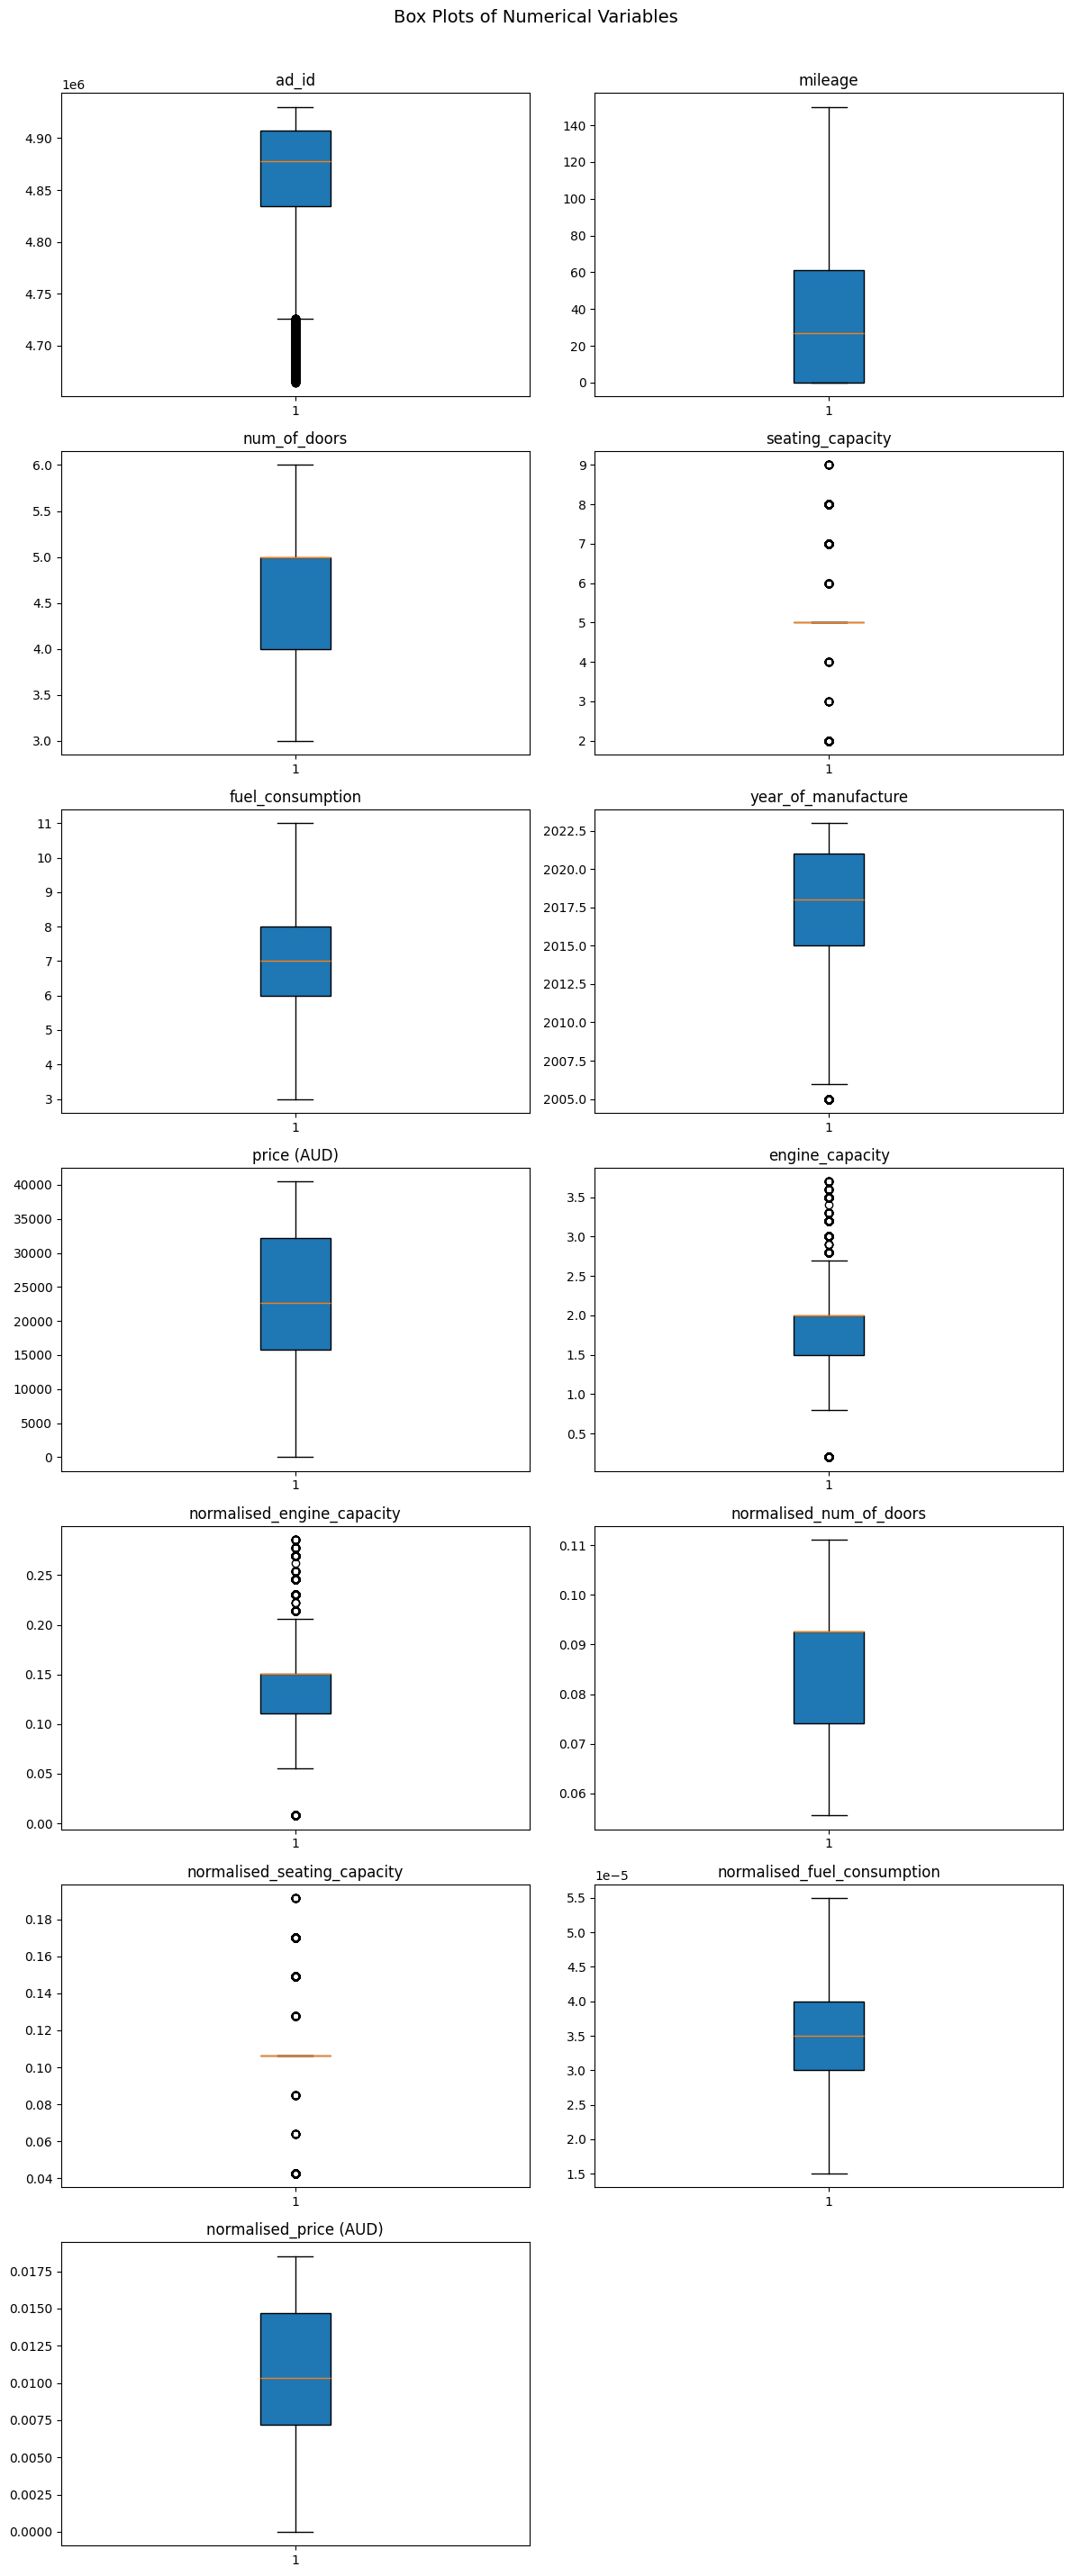

In [26]:
# Visualise boxplot to see outliers
numeric_cols = cleaned_car_data.select_dtypes(include=['float64', 'int64']).columns
n = len(numeric_cols)

cols = 2 #make it 2 cols
rows = (n + 1) // cols

fig, axs = plt.subplots(rows, cols, figsize=(12, 4 * rows)) #create graph
axs = axs.flatten()

# Create boxplot
for i, col in enumerate(numeric_cols): #create boxplot
    axs[i].boxplot(cleaned_car_data[col].dropna(), patch_artist=True)
    axs[i].set_title(col)

# Delete spaces
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.suptitle("Box Plots of Numerical Variables", fontsize=14, y=1.02)
plt.show()

In [15]:
# identify and treat missing value
# show missing values
missing_before = cleaned_car_data.isnull().sum()
print("\nMissing values BEFORE imputation:\n", missing_before[missing_before > 0])

# fill missing value
for col in cleaned_car_data.columns:
    if cleaned_car_data[col].isnull().sum() > 0:
        if cleaned_car_data[col].dtype in ['float64', 'int64']:
            cleaned_car_data[col] = cleaned_car_data[col].fillna(cleaned_car_data[col].median())
        else:
            cleaned_car_data[col] = cleaned_car_data[col].fillna(cleaned_car_data[col].mode()[0])

# recheck missing value after filling
missing_after = cleaned_car_data.isnull().sum()
print("\nMissing values AFTER imputation:\n", missing_after[missing_after > 0])

# count the row before and after cleaning
print(f"Dataset Before cleaning: {car_data.shape[0]} rows")
print(f"\nFinal dataset after cleaning: {cleaned_car_data.shape[0]} rows")


Missing values BEFORE imputation:
 fuel_system                    16616
fuel_consumption               13139
year_of_manufacture               13
engine_capacity                  697
normalised_engine_capacity       697
normalised_fuel_consumption    13139
dtype: int64

Missing values AFTER imputation:
 Series([], dtype: int64)
Dataset Before cleaning: 30652 rows

Final dataset after cleaning: 21169 rows


### **Part 3: Data Storage**

In [16]:
import sqlite3

#loading cleaned/processed data
cars_df = pd.read_csv("processed_car_dataset.csv")
sellers_df = pd.read_csv("seller_dataset.csv")

cars_df.head(), sellers_df.head()

(   ad_id             origin condition  car_model  mileage exterior_color  \
 0  17042  domestic assembly   new car      truck        0          white   
 1  53794           imported   new car        suv        0          black   
 2  73954  domestic assembly   new car  crossover        0         silver   
 3  74150           imported   new car        suv        0          white   
 4  87573  domestic assembly   new car  crossover        0         silver   
 
   interior_color  num_of_doors  seating_capacity         engine  ...  \
 0           gray             2                 2  Petrol\t1.0 L  ...   
 1          black             5                 7  Petrol\t3.4 L  ...   
 2          brown             5                 8  Petrol\t2.0 L  ...   
 3          black             5                 5  Petrol\t1.8 L  ...   
 4           gray             5                 8  Petrol\t2.0 L  ...   
 
   year_of_manufacture                              car_name   price (AUD)  \
 0              20

In [17]:
# Connecting to SQLite db
conn = sqlite3.connect("car_sales.db")
cursor = conn.cursor()

# creating cars table 

cursor.execute("""
               
CREATE TABLE IF NOT EXISTS Cars (
    ad_id INTEGER PRIMARY KEY,
    car_name VARCHAR(255),
    origin VARCHAR(255),
    condition VARCHAR(255),
    exterior_color VARCHAR(255),
    car_model VARCHAR(255),
    year_of_manufacture VARCHAR(255),
    transmission VARCHAR(255),
    price INTEGER,
    drive_type VARCHAR(255)
);
               
""") 


# creating sellers Table

cursor.execute("""
               
CREATE TABLE IF NOT EXISTS Sellers (
    ad_id INTEGER PRIMARY KEY,
    seller_name TEXT
);

""")


# Inserting cars and sellers data into the tables
cars_df = cars_df.rename(columns={"price (AUD)": "price"}) #SQLite has issues with spaces and paranthesis
cars_df[[
    "ad_id", "car_name", "origin", "condition", "exterior_color","car_model", 
    "year_of_manufacture", "transmission", "price", "drive_type"
]].to_sql("Cars", conn, if_exists="replace", index=False)


sellers_df[["ad_id", "name"]].to_sql("Sellers", conn, if_exists="replace", index=False)


# Joining cars and sellers table based on ad_id attribute

query = """
SELECT Cars.ad_id, Cars.car_name, Cars.price, Sellers.name
FROM Cars
JOIN Sellers
ON Cars.ad_id = Sellers.ad_id
LIMIT 10;
"""
result = pd.read_sql(query, conn)
result



,ad_id,car_name,price,name
0,17042,Suzuki Super Carry Truck 1.0 MT 2022,10080.99411,Suzuki - Sydney
1,53794,Toyota Land Cruiser 3.5 V6 2022,161943.68050,Toyota - Melbourne
2,73954,Toyota Innova G 2.0 AT 2023 car,35830.03930,Toyota - Brisbane
3,74150,Toyota Corolla Cross 1.8G 2023,30526.38376,Toyota - Perth
4,87573,Toyota Innova G 2.0 AT 2022 car,34413.03209,Toyota - Adelaide
5,97011,Suzuki Super Carry Van Blind Van 2023,12105.29011,Suzuki - Canberra
6,101726,Honda CRV L 2023 car,39838.14539,Honda - Darwin
7,135739,Toyota Fortuner 2.7L 4x2 AT 2023,40485.92011,Toyota - Hobart
8,142495,Ford Ranger XLS 2.0L 4x2 AT 2023,27854.31303,Ford - Gold Coast
9,143308,Ford Ranger XLT 2.0L 4x4 AT 2023,33603.31369,Ford - Newcastle


# **4. Data Visualization**

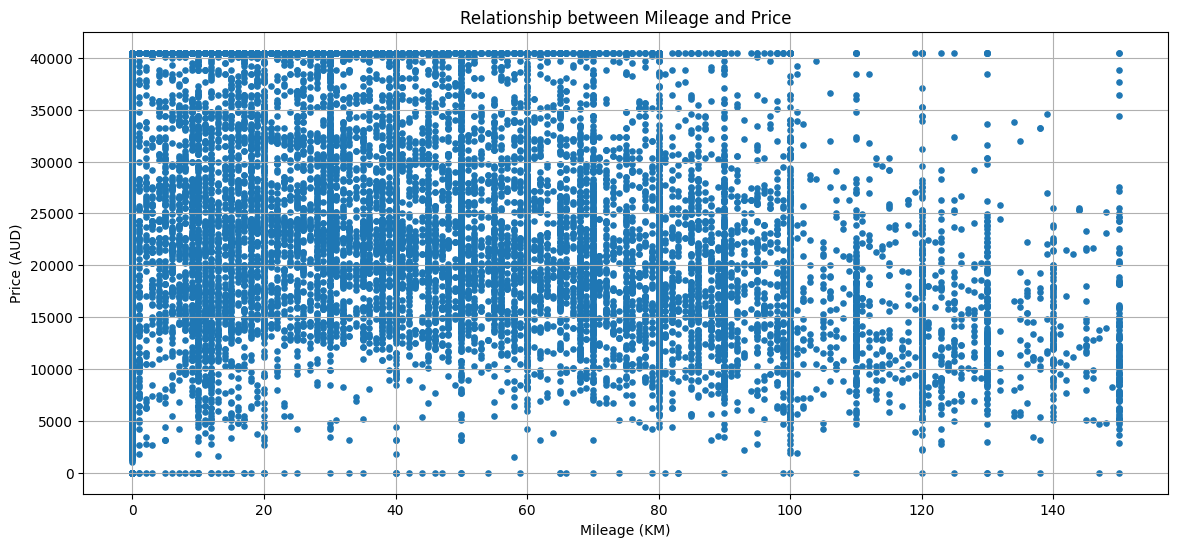

In [18]:
# 4.1 Examine the relationship between 'mileage' and 'price' (scatter plot)
plt.figure(figsize = (14, 6))

# Scatter plot: X = mileage (KM), Y = price (AUD)
plt.scatter(cleaned_car_data["mileage"], cleaned_car_data["price (AUD)"], s = 14, alpha = 1)
plt.title("Relationship between Mileage and Price", fontsize = 12)
plt.xlabel("Mileage (KM)", fontsize = 10)
plt.ylabel("Price (AUD)", fontsize = 10)
plt.grid(True)
plt.show()

# Findings - Cars with lower mileage generally have higher prices. 
# However, the data points are widely scattered with many overlaps, suggesting that only mileage is not a strong predictor of price.

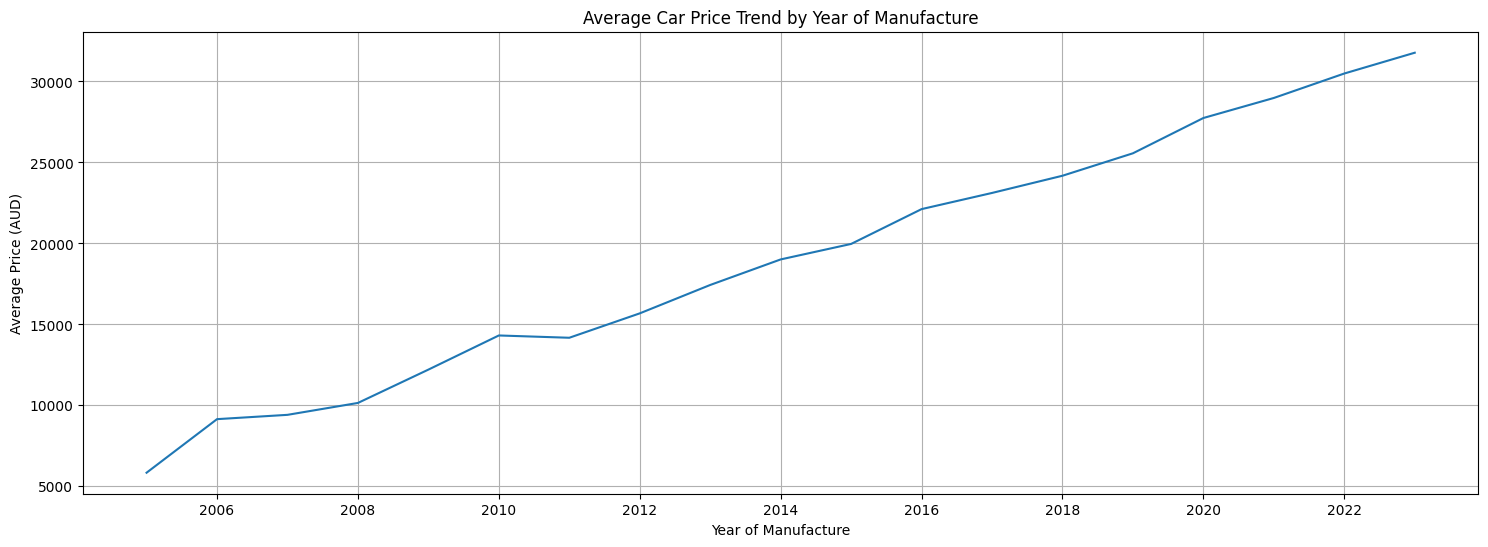

In [19]:
# 4.2 Analyze the trend of car prices over the 'year_of_m' (Line chart)

# Group by year and compute the mean price per year
avg_price_by_year = cleaned_car_data.groupby('year_of_manufacture')['price (AUD)'].mean()

plt.figure(figsize = (18, 6))

# Plot the line: X = year, Y = average price
plt.plot(avg_price_by_year.index, avg_price_by_year.values, linestyle = '-')

# Force integer ticks on X-axis
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.title('Average Car Price Trend by Year of Manufacture', fontsize = 12)
plt.xlabel('Year of Manufacture', fontsize = 10)
plt.ylabel('Average Price (AUD)', fontsize = 10)
plt.xticks(rotation = 0)
plt.grid(True)
plt.show()

# Findings - Car prices steady incresed from 2005 to 2023, from just above 5000 AUD to around 35000 AUD. 
# This indicates that newer cars tend to be more expensive.

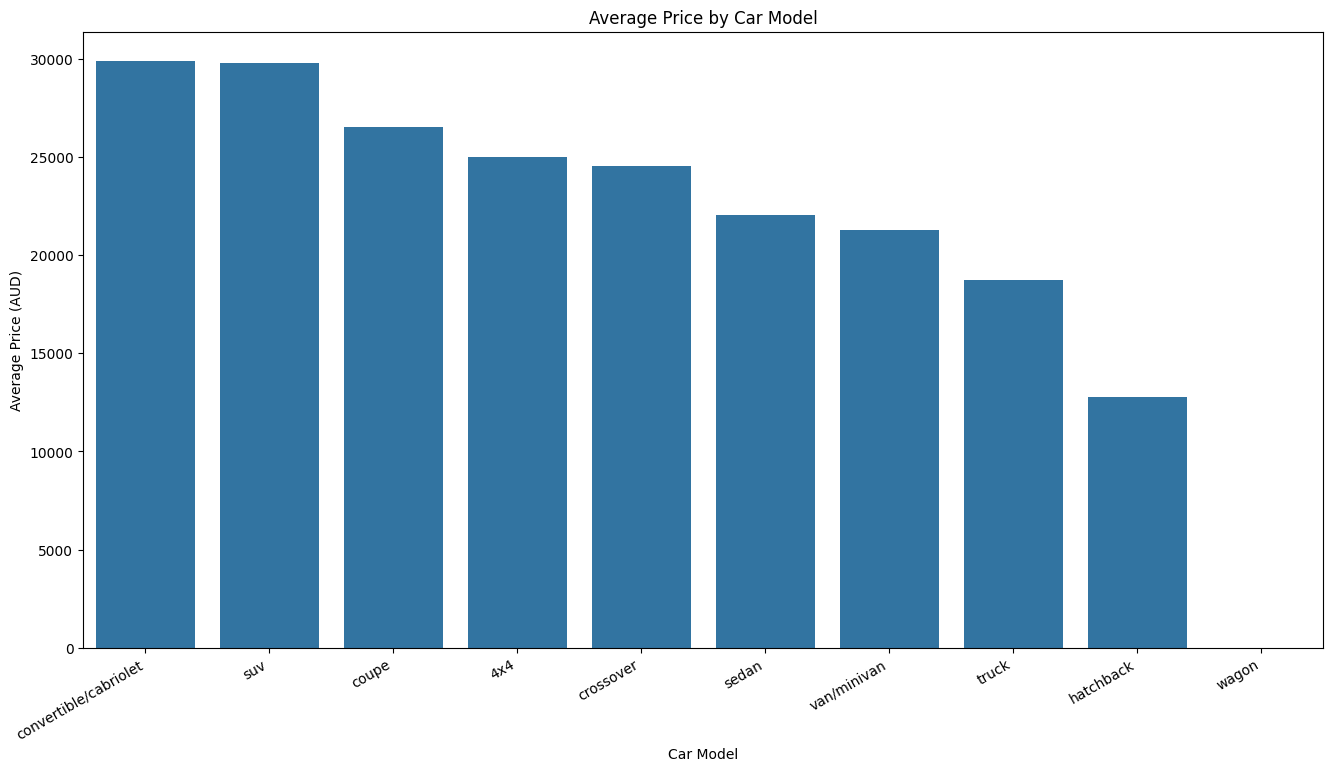

In [20]:
# 4.3 Compare the average prices among different 'car_models' (bar chart)

# Group by car_model and compute mean price
avg_price_by_model = cleaned_car_data.groupby('car_model')['price (AUD)'].mean()

# Sort by average price (descending) for clearer comparison
sorted_avg_price = avg_price_by_model.sort_values(ascending = False)

plt.figure(figsize = (16, 8))

# Bar chart: X = car_model (sorted), Y = avg price
sns.barplot(x = sorted_avg_price.index, y = sorted_avg_price.values)
plt.title('Average Price by Car Model', fontsize = 12)
plt.xlabel('Car Model', fontsize = 10)
plt.ylabel('Average Price (AUD)', fontsize = 10)
plt.xticks(rotation = 30, ha = 'right')
plt.show()

# Findings - Convertible/cabriolet models and SUV models have the highest average prices, followed by coupes and 4x4s.

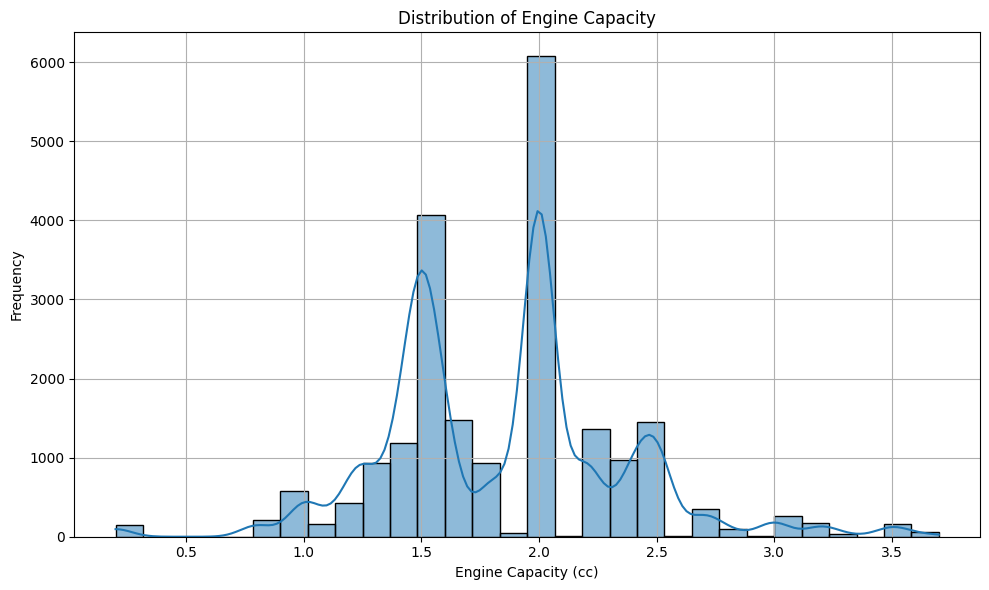

In [21]:
# Display the distribution of 'engine_capacity'
plt.figure(figsize=(10, 6))
sns.histplot(cleaned_car_data['engine_capacity'], bins=30, kde=True, edgecolor='black')

plt.title("Distribution of Engine Capacity", fontsize=12)
plt.xlabel("Engine Capacity (cc)", fontsize=10)
plt.ylabel("Frequency", fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

# Findings - Most cars have engine capacities around 1.5L and 2.0L. The shape is right-skewed, meaning larger engines are less common.

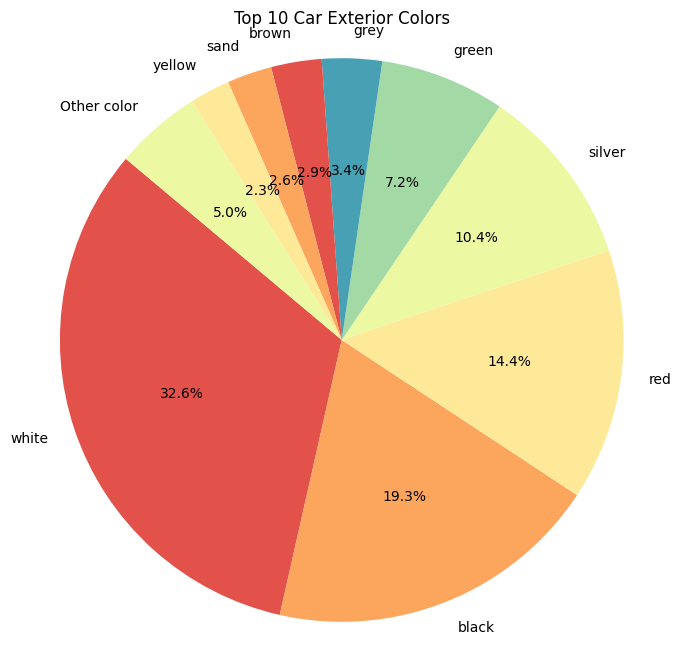

In [22]:
# Visualise the distribution of the cars’ exterior colors as the percentage of a whole
# Group by 'exterior_color'
top_n = 9
color_counts = cleaned_car_data['exterior_color'].value_counts()
top_colors = color_counts[:top_n]
other_total = color_counts[top_n:].sum() #group the rest as other for easy readability 

# Combine into new series
color_combined = top_colors.copy()
color_combined['Other color'] = other_total
color_percent = color_combined / color_combined.sum() * 100

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(color_percent, 
        labels=color_percent.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=sns.color_palette('Spectral'))

plt.title('Top 10 Car Exterior Colors')
plt.axis('equal')
plt.show()

# Findings - White is the most popular car color (32.6%), followed by red (19.3%) and silver (10.4%).

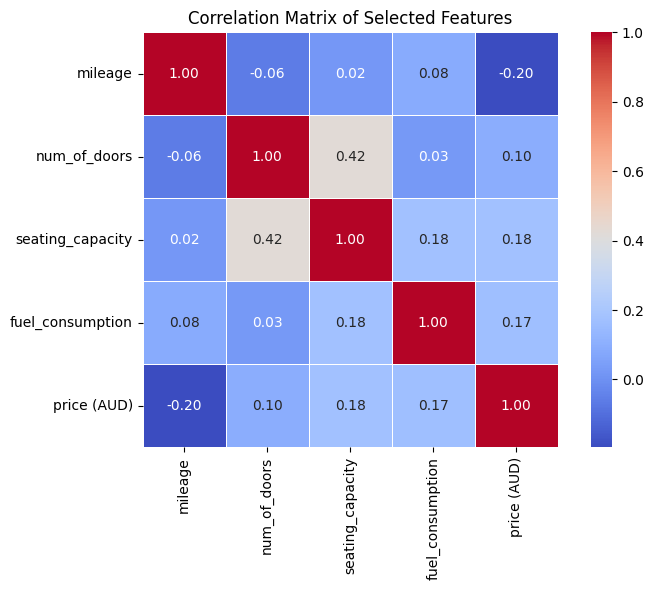

In [23]:
# Visualise/Identify correlations between these features:
# 'mileage','num_of_doors', 'seating_capacity', 'fuel_consumption', and 'price'
# Select features
features = ['mileage', 'num_of_doors', 'seating_capacity', 'fuel_consumption', 'price (AUD)']
corr_matrix = cleaned_car_data[features].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap="coolwarm", 
            square=True, 
            linewidths=0.5)

plt.title("Correlation Matrix of Selected Features")
plt.tight_layout()
plt.show()

# Findings - Variables show weak relationships with each other (weak correlation). 
# Mileage is slightly negatively correlated with price (-0.20), while seating capacity moderately correlates with number of doors (0.42).